# Naturutbygging i Norge (Dynamic World, overgangslogikk)

## Metode (Google Earth Engine)
Denne analysen bygger på *Dynamic World* (built-sannsynlighet) aggregert for sommerperioden (1. juni–1. september) i Google Earth Engine. Hovedstegene er:

1. **Sommerfilter**: Henter Dynamic World-bilder innenfor tidsvinduet for hvert år (2023, 2024, 2025).
2. **Fast analysegrid**: Downsampler sannsynlighet til et fast rutenett (f.eks. 100 m) før års-gjennomsnitt beregnes.
3. **Terskling til binær bygd/ikke-bygd**: Piksel klassifiseres som *bygd* dersom gjennomsnittlig built-sannsynlighet ≥ terskel (typisk 0.5–0.7).
4. **Overgangslogikk (transition)**: Ny utbygging måles som overganger **ikke-bygd → bygd** mellom år (GAIN). Vi beregner også LOSS (bygd → ikke-bygd) og NET = GAIN − LOSS som en kvalitetssjekk.
5. **Aggregering per kommune (KID)**: Pikselareal summeres innenfor kommune-ID-rasteret, og eksporteres som CSV.

**Viktig tolkning:** `gain_km2_*` er et mer robust mål på *nyklassifisert utbygging* enn differanse i total built-bestand, fordi det eksplisitt teller overganger.


## 1) Last inn data
Notebooken forventer tre filer i samme mappe som notebooken:

- `built_per_kid_2023_2025_summer_transitions_*.csv` (output fra GEE med overgangslogikk)
- `robek_listen.csv` (ROBEK sommeren 2023; kolonner: `kommunenr, kommune, fylke`)
- `kommunenummer.csv` (Kartverket/Geonorge; semikolon-separert; kolonner bl.a. `Navn;Kodeverdi;Status`)

Vi kobler deretter på kommunenavn og en ROBEK-indikator (1/0).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob
from matplotlib.colors import PowerNorm

sns.set_context('notebook')

# ---- Filnavn (auto-finn hvis du ikke vil hardkode) ----
DATA_FILE = 'built_per_kid_2023_2025_summer_transitions.csv'  # valgfritt navn
ROBEK_FILE = 'robek_listen.csv'
KOMMUNE_FILE = 'kommunenummer.csv'

# Finn transitions-csv automatisk hvis DATA_FILE ikke finnes
if not Path(DATA_FILE).exists():
    matches = sorted(glob.glob('built_per_kid_2023_2025_summer_transitions_*.csv'))
    if len(matches) == 0:
        raise FileNotFoundError('Fant ingen transitions-CSV. Legg filen i samme mappe, eller oppdater DATA_FILE.')
    DATA_FILE = matches[0]

df = pd.read_csv(DATA_FILE)

# ROBEK: kommunenr, kommune, fylke  -> robek=1
robek = pd.read_csv(ROBEK_FILE)
robek = robek.rename(columns={'kommunenr': 'kid'})
robek['kid'] = pd.to_numeric(robek['kid'], errors='coerce').astype('Int64')
robek = robek.dropna(subset=['kid'])
robek['kid'] = robek['kid'].astype(int)
robek['robek'] = 1

# Kommunenummer: semikolon-separert, Navn;Kodeverdi;Status;...
kommuner = pd.read_csv(KOMMUNE_FILE, sep=';', dtype=str)
kommuner = kommuner.rename(columns={'Navn': 'kommune', 'Kodeverdi': 'kid'})
kommuner['kid'] = kommuner['kid'].str.strip()
kommuner['kid'] = pd.to_numeric(kommuner['kid'], errors='coerce').astype('Int64')
kommuner = kommuner.dropna(subset=['kid'])
kommuner['kid'] = kommuner['kid'].astype(int)

# Ta helst med 'Gyldig' kommunenavn (men behold fallback hvis noen mangler)
kommuner_valid = kommuner.copy()
if 'Status' in kommuner_valid.columns:
    kommuner_valid = kommuner_valid[kommuner_valid['Status'].str.strip().eq('Gyldig')]

# Merge: navn + ROBEK
df['kid'] = pd.to_numeric(df['kid'], errors='coerce').astype('Int64')
df = df.dropna(subset=['kid']).copy()
df['kid'] = df['kid'].astype(int)

df = df.merge(kommuner_valid[['kid', 'kommune']].drop_duplicates('kid'), on='kid', how='left')
# fallback til alle kommuner hvis noen mangler
missing = df['kommune'].isna()
if missing.any():
    df = df.merge(kommuner[['kid','kommune']].drop_duplicates('kid'), on='kid', how='left', suffixes=('', '_fallback'))
    df['kommune'] = df['kommune'].fillna(df['kommune_fallback'])
    df = df.drop(columns=[c for c in ['kommune_fallback'] if c in df.columns])

df = df.merge(robek[['kid','robek']], on='kid', how='left')
df['robek'] = df['robek'].fillna(0).astype(int)

# Sjekk at forventede kolonner finnes
expected = [
    'built_km2_2023','built_km2_2024','built_km2_2025',
    'gain_km2_23_24','gain_km2_24_25','gain_km2_23_25',
    'loss_km2_23_24','loss_km2_24_25','loss_km2_23_25',
    'net_km2_23_24','net_km2_24_25','net_km2_23_25'
]
missing_cols = [c for c in expected if c not in df.columns]
if missing_cols:
    raise ValueError('Mangler forventede kolonner i transitions-CSV: ' + ', '.join(missing_cols))

# For lesbarhet
df['kommune'] = df['kommune'].fillna(df['kid'].astype(str))
df.head()

,kid,built_km2_2023,built_km2_2024,built_km2_2025,gain_km2_23_24,loss_km2_23_24,net_km2_23_24,gain_km2_24_25,loss_km2_24_25,net_km2_24_25,gain_km2_23_25,loss_km2_23_25,net_km2_23_25,delta_km2_23_24,delta_km2_24_25,delta_km2_23_25,kommune,robek
0,301,102.521692,94.578770,91.147874,1.280966,9.223889,-7.942922,2.192104,5.623000,-3.430896,1.027300,12.401119,-11.373819,1.280966,2.192104,1.027300,Oslo,0
1,1101,6.695701,6.838823,6.097173,0.882133,0.739011,0.143122,0.626275,1.367924,-0.741650,0.427660,1.026188,-0.598528,0.882133,0.626275,0.427660,Eigersund,0
2,1103,39.712661,37.245136,36.988981,1.242548,3.710073,-2.467525,2.186567,2.442722,-0.256155,0.874688,3.598368,-2.723680,1.242548,2.186567,0.874688,Stavanger,0
3,1106,13.730406,13.618655,13.292423,0.384136,0.495888,-0.111752,0.277584,0.603815,-0.326231,0.258183,0.696166,-0.437983,0.384136,0.277584,0.258183,Haugesund,0
4,1108,27.089756,26.169467,23.724218,1.559119,2.479408,-0.920289,1.285291,3.730540,-2.445249,0.768404,4.133943,-3.365539,1.559119,1.285291,0.768404,Sandnes,0


## 2) Nasjonal tidsserie: akkumulert *ny utbygging* (GAIN)
Vi bruker `gain_km2_23_24` og `gain_km2_24_25` som årlige tilskudd (ny utbygging via overganger). Deretter lager vi en enkel akkumulert kurve.

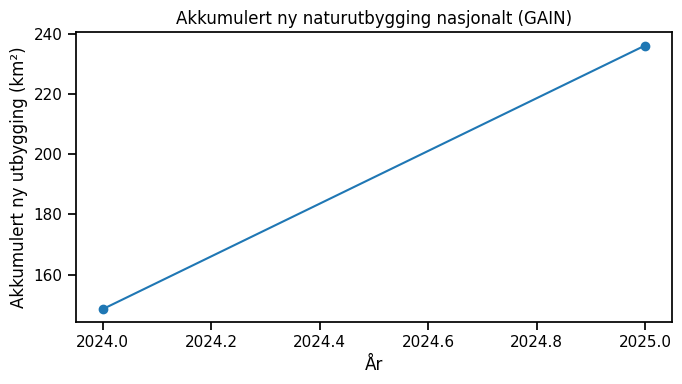

2024    148.607522
2025     87.460346
dtype: float64

In [2]:
national_gain = pd.Series({
    2024: df['gain_km2_23_24'].sum(),
    2025: df['gain_km2_24_25'].sum(),
}).sort_index()

national_cum = national_gain.cumsum()

plt.figure(figsize=(7,4))
national_cum.plot(marker='o')
plt.ylabel('Akkumulert ny utbygging (km²)')
plt.xlabel('År')
plt.title('Akkumulert ny naturutbygging nasjonalt (GAIN)')
plt.tight_layout()
plt.show()

national_gain

## 3) Heat map: utbygging per kommune (sensitiv fargeskala)
Heat mapet viser `gain_km2_23_25` per kommune. For å få frem flere nyanser bruker vi en *PowerNorm* (gamma < 1) som øker kontrasten i lave og middels verdier uten log-transformasjon.

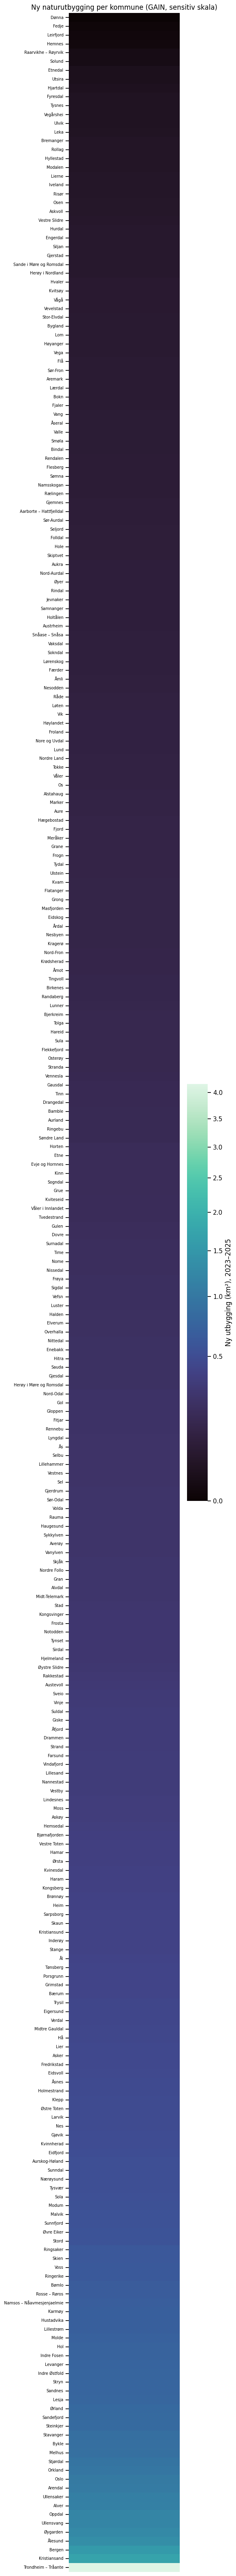

In [3]:
heat = (df[['kommune','kid','gain_km2_23_25']]
        .sort_values('gain_km2_23_25')
        .reset_index(drop=True))

# Bygg matrise (n x 1) for heatmap
mat = heat[['gain_km2_23_25']].to_numpy()

plt.figure(figsize=(6, max(6, 0.22*len(heat))))
ax = sns.heatmap(
    mat,
    cmap='mako',
    norm=PowerNorm(gamma=0.5),
    cbar_kws={'label': 'Ny utbygging (km²), 2023–2025'}
)
ax.set_yticks(np.arange(len(heat)) + 0.5)
ax.set_yticklabels(heat['kommune'], fontsize=7)
ax.set_xticks([])
plt.title('Ny naturutbygging per kommune (GAIN, sensitiv skala)')
plt.tight_layout()
plt.show()

## 4) ROBEK vs. øvrige kommuner
Vi sammenligner gjennomsnittlig ny utbygging per kommune (`gain_km2_23_25`) mellom ROBEK-kommuner og øvrige kommuner. Tabellen viser også antall kommuner og median for robusthet.

In [4]:
comp = (df.groupby('robek')
          .agg(
              n=('kid','nunique'),
              mean_gain_km2=('gain_km2_23_25','mean'),
              median_gain_km2=('gain_km2_23_25','median'),
              sum_gain_km2=('gain_km2_23_25','sum')
          )
          .reset_index())

comp['gruppe'] = comp['robek'].map({0:'Ikke ROBEK', 1:'ROBEK'})
comp = comp[['gruppe','n','mean_gain_km2','median_gain_km2','sum_gain_km2']]
comp = comp.sort_values('gruppe')

comp.style.format({
    'mean_gain_km2': '{:.3f}',
    'median_gain_km2': '{:.3f}',
    'sum_gain_km2': '{:.3f}'
})

,gruppe,n,mean_gain_km2,median_gain_km2,sum_gain_km2
0,Ikke ROBEK,285,0.308,0.211,87.737
1,ROBEK,5,0.163,0.152,0.814


## 5) Toppliste: Top 20 kommuner etter ny utbygging (2023–2025)
Topplisten rangerer kommuner etter `gain_km2_23_25`. ROBEK-status er inkludert.

In [5]:
top20 = (df[['kid','kommune','robek','gain_km2_23_25','gain_km2_23_24','gain_km2_24_25']]
         .sort_values('gain_km2_23_25', ascending=False)
         .head(20)
         .reset_index(drop=True))

top20['robek'] = top20['robek'].map({0:'', 1:'ROBEK'})

top20.style.format({
    'gain_km2_23_25': '{:.3f}',
    'gain_km2_23_24': '{:.3f}',
    'gain_km2_24_25': '{:.3f}'
})

,kid,kommune,robek,gain_km2_23_25,gain_km2_23_24,gain_km2_24_25
0,5001,Trondheim – Tråante,,4.165,4.033,4.633
1,4204,Kristiansand,,1.720,3.321,0.644
2,4601,Bergen,,1.553,3.574,1.891
3,1508,Ålesund,,1.354,1.761,2.447
4,4626,Øygarden,,1.276,2.824,0.933
5,4618,Ullensvang,,1.200,1.712,0.294
6,5021,Oppdal,,1.197,1.274,0.453
7,4631,Alver,,1.130,3.106,0.618
8,3209,Ullensaker,,1.114,1.630,0.523
9,4203,Arendal,,1.041,1.532,0.892


## 6) Fordeling: ny utbygging per kommune
Histogrammet viser fordelingen av `gain_km2_23_25` på tvers av kommuner (uten log-transformasjon).

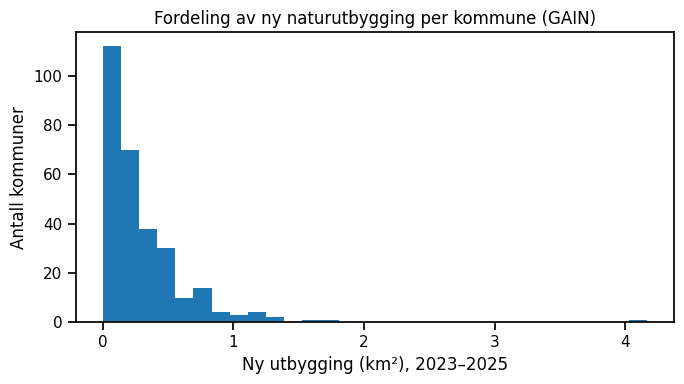

In [6]:
plt.figure(figsize=(7,4))
plt.hist(df['gain_km2_23_25'], bins=30)
plt.xlabel('Ny utbygging (km²), 2023–2025')
plt.ylabel('Antall kommuner')
plt.title('Fordeling av ny naturutbygging per kommune (GAIN)')
plt.tight_layout()
plt.show()

## 7) Kvalitetssjekk (valgfri): GAIN vs. LOSS og NET
`loss_km2_*` og `net_km2_*` kan brukes som kvalitetssjekk for hvor mye klassifikasjon/støy påvirker resultatene. Hovedmålet i prosjektet er `gain_km2_*` (overgang inn i bygd).

In [7]:
qa = pd.DataFrame({
    'periode': ['23–24','24–25','23–25'],
    'gain_km2': [df['gain_km2_23_24'].sum(), df['gain_km2_24_25'].sum(), df['gain_km2_23_25'].sum()],
    'loss_km2': [df['loss_km2_23_24'].sum(), df['loss_km2_24_25'].sum(), df['loss_km2_23_25'].sum()],
    'net_km2':  [df['net_km2_23_24'].sum(),  df['net_km2_24_25'].sum(),  df['net_km2_23_25'].sum()],
})

qa.style.format({'gain_km2':'{:.3f}','loss_km2':'{:.3f}','net_km2':'{:.3f}'})

,periode,gain_km2,loss_km2,net_km2
0,23–24,148.608,269.791,-121.183
1,24–25,87.460,284.218,-196.758
2,23–25,88.551,412.609,-324.058


## 8) Sentralitetsindeks

Gjennomsnittlig utbygging per sentralitetsklasse

,sentralitet_klasse_2023,n,mean_nedbygging_km2_periode,median_nedbygging_km2_periode,mean_nedbygging_km2_per_aar,sum_nedbygging_km2_periode
0,1,5,0.462,0.420,0.231,2.308
1,2,21,0.660,0.397,0.330,13.856
2,3,52,0.419,0.340,0.210,21.811
3,4,58,0.326,0.243,0.163,18.904
4,5,91,0.261,0.186,0.130,23.720
5,6,63,0.126,0.069,0.063,7.952


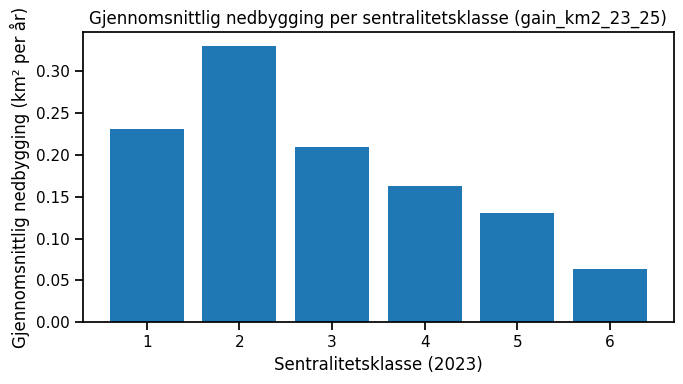

Andel kommuner uten sentralitetsklasse: 0.0%


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Fil ---
CENTRALITY_FILE = "sentralitet 2023-2024 kommuner.xlsx"

# --- Velg hva du mener med "nedbygging" (standard = ny utbygging 23–25) ---
METRIC_COL = "gain_km2_23_25"   # evt. "gain_km2_23_24" eller "gain_km2_24_25"

# 1) Les sentralitet (Excel)
sent = pd.read_excel(CENTRALITY_FILE, engine="openpyxl")
sent.columns = sent.columns.str.strip()

# Forventede kolonner: 'knr 2024', 'Kommune 2024', 'Indeks 2023', 'Klasse 2023', 'Intervall'
# Gjør robust mapping + rydd datatyper
sent = sent.rename(columns={
    "knr 2024": "kid",
    "Kommune 2024": "kommune_sent",
    "Indeks 2023": "sentralitet_indeks_2023",
    "Klasse 2023": "sentralitet_klasse_2023",
    "Intervall": "sentralitet_intervall"
})

sent["kid"] = pd.to_numeric(sent["kid"], errors="coerce").astype("Int64")
sent = sent.dropna(subset=["kid"]).copy()
sent["kid"] = sent["kid"].astype(int)

sent["sentralitet_klasse_2023"] = pd.to_numeric(
    sent["sentralitet_klasse_2023"], errors="coerce"
).astype("Int64")

# 2) Merge med analysedata (df må allerede finnes fra tidligere celler)
df2 = df.merge(
    sent[["kid", "sentralitet_klasse_2023", "sentralitet_indeks_2023", "sentralitet_intervall"]],
    on="kid",
    how="left"
)

# 3) Definer "nedbygging" som valgt metrikk
# Hvis METRIC_COL = gain_km2_23_25 er dette for perioden 2023–2025 (2 år)
df2["nedbygging_km2_periode"] = df2[METRIC_COL]

# Årlig rate (kun meningsfull hvis perioden er 2 år: 23–25)
# (For 23–24 eller 24–25 bør du IKKE dele på 2)
if METRIC_COL == "gain_km2_23_25":
    df2["nedbygging_km2_per_aar"] = df2["nedbygging_km2_periode"] / 2
else:
    df2["nedbygging_km2_per_aar"] = df2["nedbygging_km2_periode"]  # 1-årsperiode

# 4) Aggreger: snitt per sentralitetsklasse (1–6)
summary = (
    df2.dropna(subset=["sentralitet_klasse_2023"])
       .groupby("sentralitet_klasse_2023")
       .agg(
            n=("kid", "nunique"),
            mean_nedbygging_km2_periode=("nedbygging_km2_periode", "mean"),
            median_nedbygging_km2_periode=("nedbygging_km2_periode", "median"),
            mean_nedbygging_km2_per_aar=("nedbygging_km2_per_aar", "mean"),
            sum_nedbygging_km2_periode=("nedbygging_km2_periode", "sum"),
       )
       .reset_index()
       .sort_values("sentralitet_klasse_2023")
)

# 5) Vis tabell
display(
    summary.style.format({
        "mean_nedbygging_km2_periode": "{:.3f}",
        "median_nedbygging_km2_periode": "{:.3f}",
        "mean_nedbygging_km2_per_aar": "{:.3f}",
        "sum_nedbygging_km2_periode": "{:.3f}",
    })
)

# 6) Enkel figur: gjennomsnitt per sentralitetsklasse
plt.figure(figsize=(7,4))
plt.bar(
    summary["sentralitet_klasse_2023"].astype(int),
    summary["mean_nedbygging_km2_per_aar"],
)
plt.xlabel("Sentralitetsklasse (2023)")
plt.ylabel("Gjennomsnittlig nedbygging (km² per år)")
plt.title(f"Gjennomsnittlig nedbygging per sentralitetsklasse ({METRIC_COL})")
plt.xticks([1,2,3,4,5,6])
plt.tight_layout()
plt.show()

# (Valgfritt) Sjekk hvor mange kommuner som manglet sentralitet
missing_share = df2["sentralitet_klasse_2023"].isna().mean()
print(f"Andel kommuner uten sentralitetsklasse: {missing_share:.1%}")